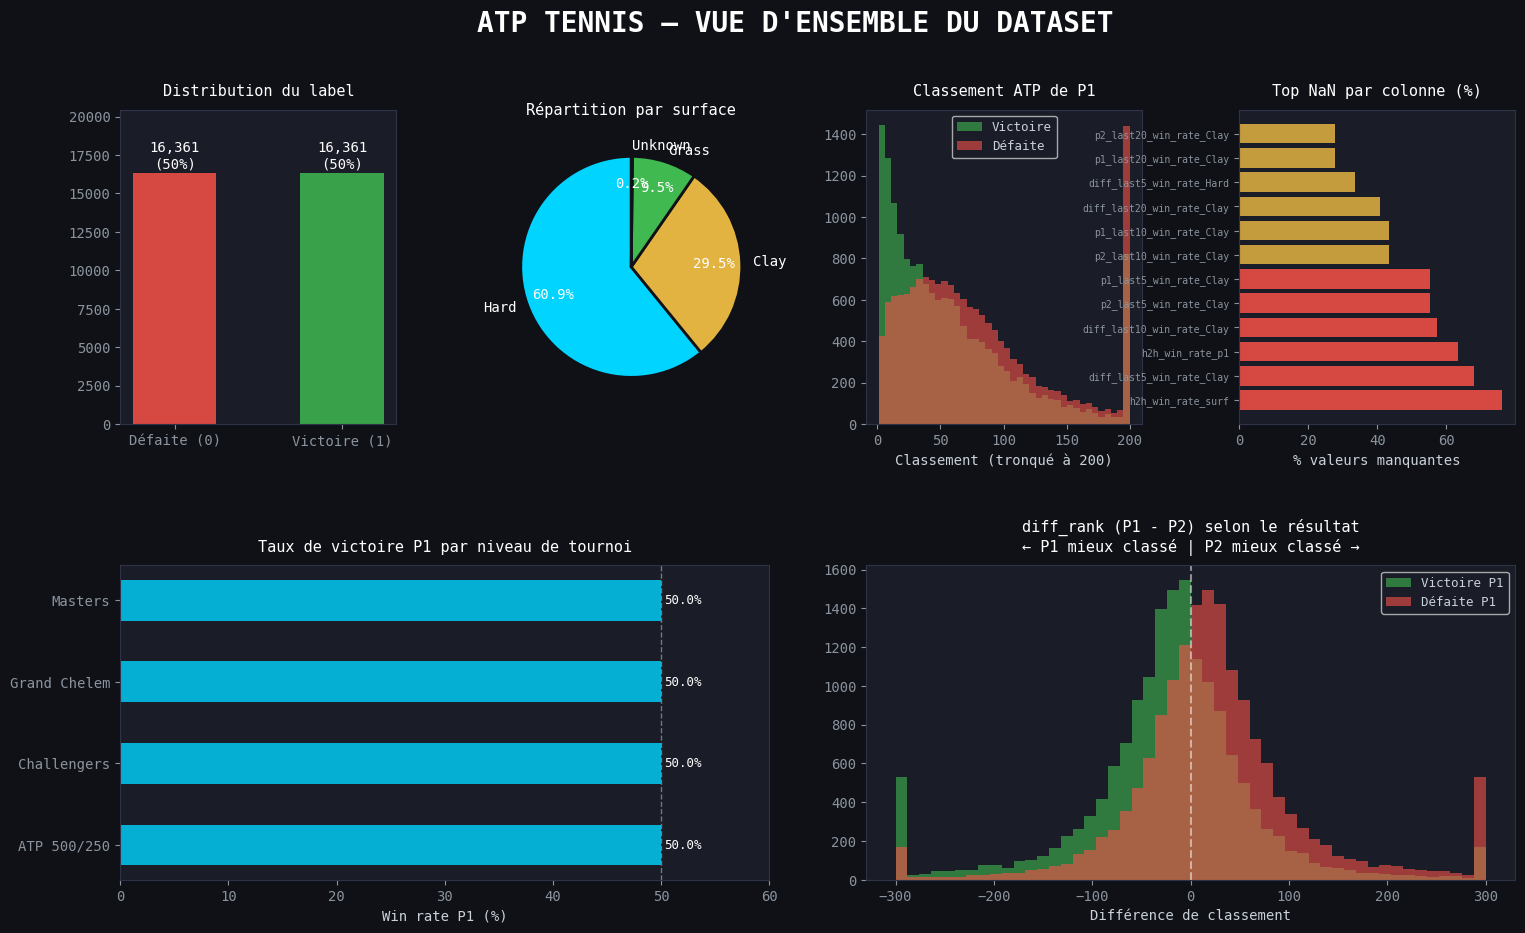

✅ Figure 1 sauvegardée → viz_overview.png


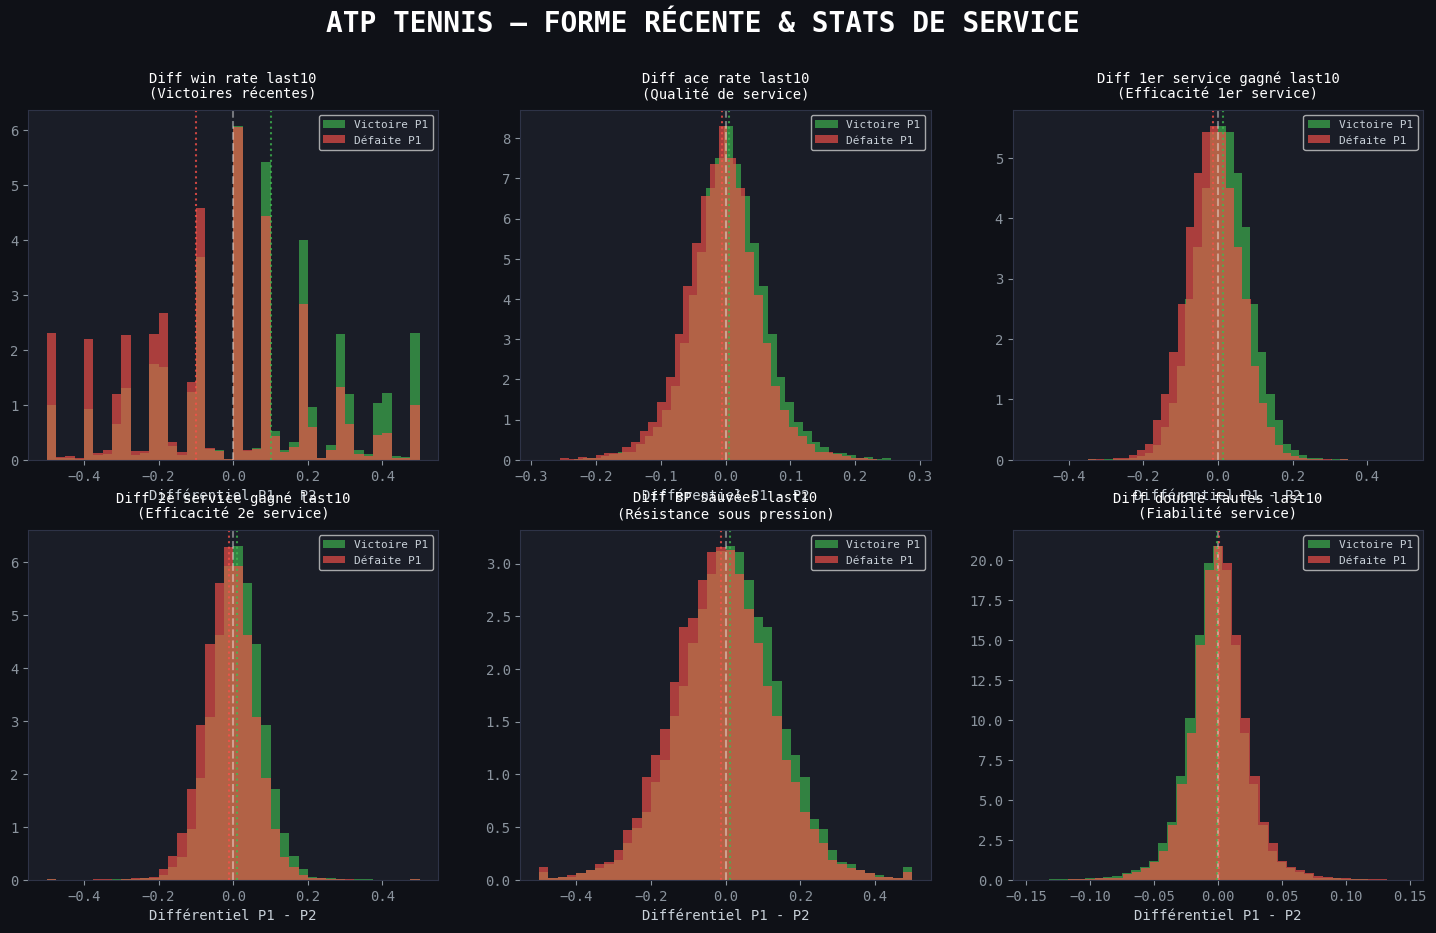

✅ Figure 2 sauvegardée → viz_rolling.png


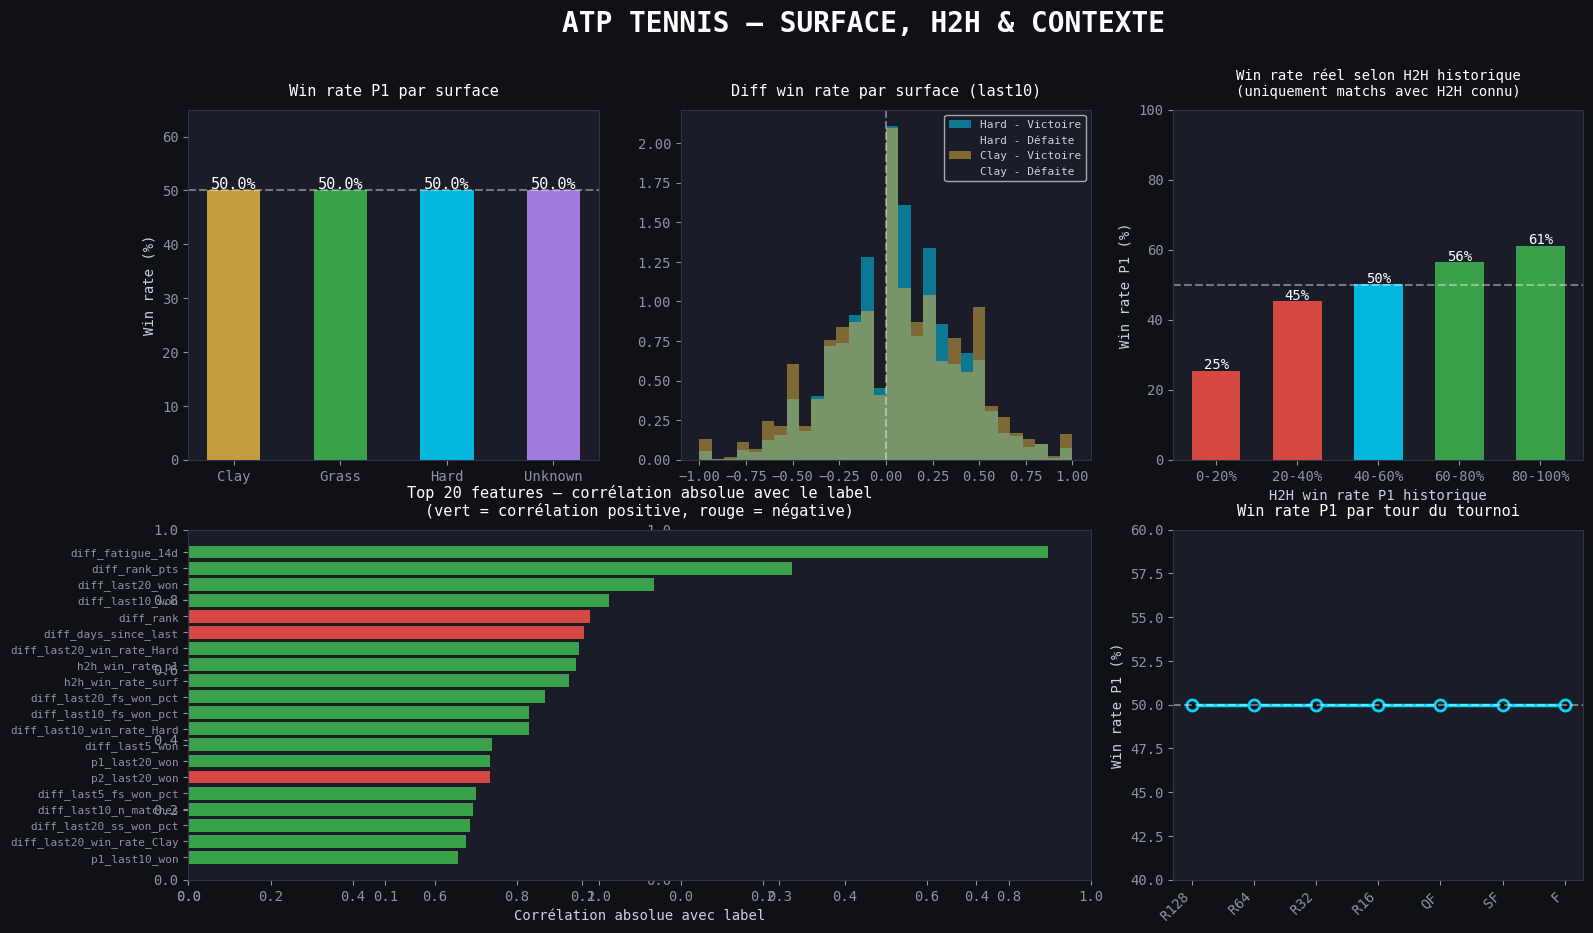

✅ Figure 3 sauvegardée → viz_surface_h2h.png


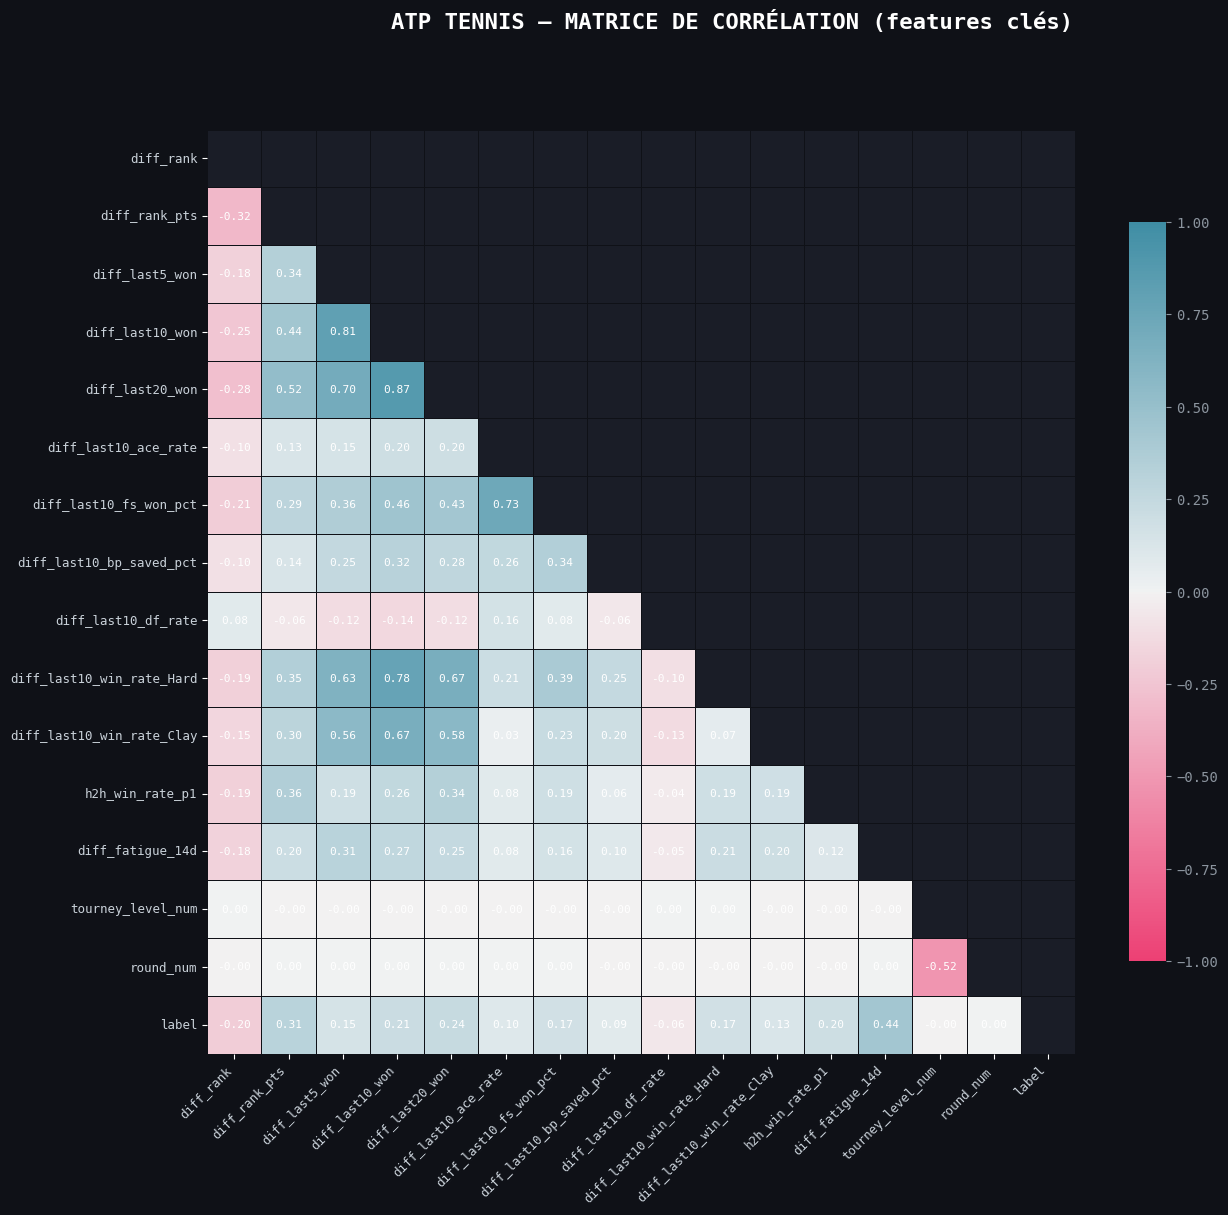

✅ Figure 4 sauvegardée → viz_correlation.png

  ✅ Toutes les visualisations générées :
     - viz_overview.png    (vue d'ensemble)
     - viz_rolling.png     (forme récente)
     - viz_surface_h2h.png (surface & H2H)
     - viz_correlation.png (corrélations)


In [ ]:
# ============================================================
# ÉTAPE 3 : VISUALISATION DES FEATURES — ANALYSE EXPLORATOIRE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

# ── Style global ──
plt.rcParams.update({
    "figure.facecolor"  : "#0f1117",
    "axes.facecolor"    : "#1a1d27",
    "axes.edgecolor"    : "#2e3347",
    "axes.labelcolor"   : "#c9d1d9",
    "axes.titlecolor"   : "#ffffff",
    "xtick.color"       : "#8b949e",
    "ytick.color"       : "#8b949e",
    "text.color"        : "#c9d1d9",
    "grid.color"        : "#2e3347",
    "grid.linestyle"    : "--",
    "grid.alpha"        : 0.5,
    "font.family"       : "monospace",
})

ACCENT   = "#00d4ff"
GREEN    = "#3fb950"
RED      = "#f85149"
ORANGE   = "#e3b341"
PURPLE   = "#bc8cff"
SURFACES = {"Hard": ACCENT, "Clay": ORANGE, "Grass": GREEN}

df = pd.read_parquet("../../data/tennis/atp_features_clean_final.parquet")

# Reconstruction surface depuis one-hot
def get_surface(row):
    if row.get("surf_Hard", 0)  == 1: return "Hard"
    if row.get("surf_Clay", 0)  == 1: return "Clay"
    if row.get("surf_Grass", 0) == 1: return "Grass"
    return "Unknown"

df["surface"] = df.apply(get_surface, axis=1)

# ─────────────────────────────────────────────────────────────
# FIGURE 1 — VUE D'ENSEMBLE DU DATASET
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 10), facecolor="#0f1117")
fig.suptitle("ATP TENNIS — VUE D'ENSEMBLE DU DATASET", 
             fontsize=20, fontweight="bold", color="white",
             fontfamily="monospace", y=0.98)

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── 1a. Distribution des labels ──
ax = fig.add_subplot(gs[0, 0])
counts = df["label"].value_counts()
bars = ax.bar(["Défaite (0)", "Victoire (1)"], counts.values,
              color=[RED, GREEN], alpha=0.85, width=0.5, edgecolor="none")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{val:,}\n({val/len(df):.0%})", ha="center", va="bottom",
            fontsize=10, color="white", fontfamily="monospace")
ax.set_title("Distribution du label", fontsize=11, pad=10)
ax.set_ylim(0, counts.max() * 1.25)
ax.grid(axis="x", visible=False)

# ── 1b. Matchs par surface ──
ax = fig.add_subplot(gs[0, 1])
surf_counts = df[df["label"]==1]["surface"].value_counts()
colors_surf = [SURFACES.get(s, PURPLE) for s in surf_counts.index]
wedges, texts, autotexts = ax.pie(
    surf_counts.values, labels=surf_counts.index,
    colors=colors_surf, autopct="%1.1f%%",
    startangle=90, pctdistance=0.75,
    wedgeprops={"edgecolor": "#0f1117", "linewidth": 2}
)
for t in texts + autotexts:
    t.set_color("white"); t.set_fontsize(10)
ax.set_title("Répartition par surface", fontsize=11, pad=10)

# ── 1c. Distribution du classement P1 ──
ax = fig.add_subplot(gs[0, 2])
for label, color, name in [(1, GREEN, "Victoire"), (0, RED, "Défaite")]:
    data = df[df["label"]==label]["p1_rank"].clip(0, 200)
    ax.hist(data, bins=40, alpha=0.6, color=color, label=name, edgecolor="none")
ax.set_title("Classement ATP de P1", fontsize=11, pad=10)
ax.set_xlabel("Classement (tronqué à 200)")
ax.legend(fontsize=9)
ax.grid(axis="x", visible=False)

# ── 1d. NaN par colonne ──
ax = fig.add_subplot(gs[0, 3])
nan_pct = df.drop(columns=["label","year","surface"], errors="ignore") \
            .isnull().mean().mul(100).sort_values(ascending=False).head(12)
bars = ax.barh(nan_pct.index, nan_pct.values,
               color=[RED if v > 50 else ORANGE if v > 20 else ACCENT
                      for v in nan_pct.values],
               alpha=0.85, edgecolor="none")
ax.set_title("Top NaN par colonne (%)", fontsize=11, pad=10)
ax.set_xlabel("% valeurs manquantes")
ax.tick_params(axis="y", labelsize=7)
ax.grid(axis="y", visible=False)

# ── 1e. Win rate par niveau de tournoi ──
ax = fig.add_subplot(gs[1, 0:2])
level_map_inv = {5:"Grand Chelem", 4:"Masters", 3:"ATP 500/250", 2:"Challengers", 1:"Autres"}
df["tourney_name"] = df["tourney_level_num"].map(level_map_inv)
wr_level = df.groupby("tourney_name")["label"].mean().sort_values(ascending=True)
bars = ax.barh(wr_level.index, wr_level.values * 100,
               color=ACCENT, alpha=0.8, edgecolor="none", height=0.5)
ax.axvline(50, color="white", linestyle="--", alpha=0.4, linewidth=1)
for bar, val in zip(bars, wr_level.values):
    ax.text(val*100 + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1%}", va="center", fontsize=9, color="white")
ax.set_title("Taux de victoire P1 par niveau de tournoi", fontsize=11, pad=10)
ax.set_xlabel("Win rate P1 (%)")
ax.set_xlim(0, 60)
ax.grid(axis="y", visible=False)

# ── 1f. Diff de classement vs victoire ──
ax = fig.add_subplot(gs[1, 2:4])
diff_win  = df[df["label"]==1]["diff_rank"].clip(-300, 300)
diff_loss = df[df["label"]==0]["diff_rank"].clip(-300, 300)
ax.hist(diff_win,  bins=50, alpha=0.6, color=GREEN, label="Victoire P1", edgecolor="none")
ax.hist(diff_loss, bins=50, alpha=0.6, color=RED,   label="Défaite P1",  edgecolor="none")
ax.axvline(0, color="white", linestyle="--", alpha=0.5, linewidth=1.5)
ax.set_title("diff_rank (P1 - P2) selon le résultat\n"
             "← P1 mieux classé | P2 mieux classé →", fontsize=11, pad=10)
ax.set_xlabel("Différence de classement")
ax.legend(fontsize=9)
ax.grid(axis="x", visible=False)

plt.savefig("../../visualisation/tennis/viz_overview.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
print("✅ Figure 1 sauvegardée → viz_overview.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 2 — FEATURES DE FORME RÉCENTE
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor="#0f1117")
fig.suptitle("ATP TENNIS — FORME RÉCENTE & STATS DE SERVICE",
             fontsize=20, fontweight="bold", color="white",
             fontfamily="monospace", y=0.98)

rolling_feats = [
    ("diff_last10_won",        "Diff win rate last10",       "Victoires récentes"),
    ("diff_last10_ace_rate",   "Diff ace rate last10",       "Qualité de service"),
    ("diff_last10_fs_won_pct", "Diff 1er service gagné last10","Efficacité 1er service"),
    ("diff_last10_ss_won_pct", "Diff 2e service gagné last10", "Efficacité 2e service"),
    ("diff_last10_bp_saved_pct","Diff BP sauvées last10",    "Résistance sous pression"),
    ("diff_last10_df_rate",    "Diff double fautes last10",  "Fiabilité service"),
]

for ax, (col, title, subtitle) in zip(axes.flat, rolling_feats):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    data_win  = df[df["label"]==1][col].dropna().clip(-0.5, 0.5)
    data_loss = df[df["label"]==0][col].dropna().clip(-0.5, 0.5)
    ax.hist(data_win,  bins=40, alpha=0.65, color=GREEN, label="Victoire P1", edgecolor="none", density=True)
    ax.hist(data_loss, bins=40, alpha=0.65, color=RED,   label="Défaite P1",  edgecolor="none", density=True)
    ax.axvline(0, color="white", linestyle="--", alpha=0.4, linewidth=1.5)

    # Médiane par groupe
    med_w = data_win.median()
    med_l = data_loss.median()
    ax.axvline(med_w, color=GREEN, linestyle=":", alpha=0.8, linewidth=1.5)
    ax.axvline(med_l, color=RED,   linestyle=":", alpha=0.8, linewidth=1.5)

    ax.set_title(f"{title}\n({subtitle})", fontsize=10, pad=8)
    ax.legend(fontsize=8)
    ax.grid(axis="x", visible=False)
    ax.set_xlabel("Différentiel P1 - P2")

plt.savefig("../../visualisation/tennis/viz_rolling.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
print("✅ Figure 2 sauvegardée → viz_rolling.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 3 — IMPACT DE LA SURFACE & H2H
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor="#0f1117")
fig.suptitle("ATP TENNIS — SURFACE, H2H & CONTEXTE",
             fontsize=20, fontweight="bold", color="white",
             fontfamily="monospace", y=0.98)

# ── 3a. Win rate par surface ──
ax = axes[0, 0]
wr_surf = df.groupby("surface")["label"].mean()
colors_s = [SURFACES.get(s, PURPLE) for s in wr_surf.index]
bars = ax.bar(wr_surf.index, wr_surf.values * 100,
              color=colors_s, alpha=0.85, edgecolor="none", width=0.5)
ax.axhline(50, color="white", linestyle="--", alpha=0.4)
for bar, val in zip(bars, wr_surf.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1%}", ha="center", fontsize=11, color="white")
ax.set_title("Win rate P1 par surface", fontsize=11, pad=10)
ax.set_ylabel("Win rate (%)")
ax.set_ylim(0, 65)
ax.grid(axis="x", visible=False)

# ── 3b. Win rate par surface spécialisée (diff win rate surface) ──
ax = axes[0, 1]
surf_cols_diff = [c for c in df.columns if "diff_last10_win_rate" in c and "Grass" not in c]
for col, color in zip(surf_cols_diff, [ACCENT, ORANGE]):
    surf_name = col.split("_")[-1]
    data_w = df[df["label"]==1][col].dropna()
    data_l = df[df["label"]==0][col].dropna()
    ax.hist(data_w, bins=30, alpha=0.5, color=color, label=f"{surf_name} - Victoire",
            edgecolor="none", density=True)
    ax.hist(data_l, bins=30, alpha=0.3, color=color, label=f"{surf_name} - Défaite",
            edgecolor="none", density=True, linestyle="dashed",
            histtype="step", linewidth=2)
ax.axvline(0, color="white", linestyle="--", alpha=0.4)
ax.set_title("Diff win rate par surface (last10)", fontsize=11, pad=10)
ax.legend(fontsize=8)
ax.grid(axis="x", visible=False)

# ── 3c. H2H : impact sur le résultat ──
ax = axes[0, 2]
df_h2h = df[df["h2h_win_rate_p1"].notna()].copy()
df_h2h["h2h_bucket"] = pd.cut(df_h2h["h2h_win_rate_p1"],
                                bins=[0, 0.2, 0.4, 0.6, 0.8, 1.01],
                                labels=["0-20%","20-40%","40-60%","60-80%","80-100%"])
h2h_wr = df_h2h.groupby("h2h_bucket", observed=True)["label"].mean()
colors_h = [RED, RED, ACCENT, GREEN, GREEN]
bars = ax.bar(h2h_wr.index, h2h_wr.values * 100,
              color=colors_h, alpha=0.85, edgecolor="none", width=0.6)
ax.axhline(50, color="white", linestyle="--", alpha=0.4)
for bar, val in zip(bars, h2h_wr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.0%}", ha="center", fontsize=10, color="white")
ax.set_title("Win rate réel selon H2H historique\n(uniquement matchs avec H2H connu)",
             fontsize=10, pad=10)
ax.set_ylabel("Win rate P1 (%)")
ax.set_ylim(0, 100)
ax.set_xlabel("H2H win rate P1 historique")
ax.grid(axis="x", visible=False)

# ── 3d. Corrélation des features avec le label ──
# Fusion des deux cellules en un seul axe large
ax = plt.subplot2grid((2, 3), (1, 0), colspan=2, fig=fig)
corr_cols = [c for c in df.columns
             if c not in ["label","year","surface","tourney_name"]
             and df[c].dtype in [np.float64, np.int64, float, int]]
corr = df[corr_cols + ["label"]].corr()["label"].drop("label")
corr_sorted = corr.abs().sort_values(ascending=False).head(20)
colors_corr = [GREEN if corr[c] > 0 else RED for c in corr_sorted.index]
ax.barh(corr_sorted.index[::-1], corr_sorted.values[::-1],
        color=colors_corr[::-1], alpha=0.85, edgecolor="none")
ax.set_title("Top 20 features — corrélation absolue avec le label\n"
             "(vert = corrélation positive, rouge = négative)",
             fontsize=11, pad=10)
ax.set_xlabel("Corrélation absolue avec label")
ax.tick_params(axis="y", labelsize=8)
ax.grid(axis="y", visible=False)

# ── 3e. Win rate par round ──
ax = axes[1, 2]
round_map = {1:"R128",2:"R64",3:"R32",4:"R16",5:"QF",6:"SF",7:"F"}
df["round_name"] = df["round_num"].map(round_map)
wr_round = df.groupby("round_num")["label"].mean()
ax.plot(wr_round.index, wr_round.values * 100,
        color=ACCENT, marker="o", linewidth=2.5,
        markersize=8, markerfacecolor="#0f1117", markeredgewidth=2)
ax.axhline(50, color="white", linestyle="--", alpha=0.4)
ax.set_xticks(list(round_map.keys()))
ax.set_xticklabels(list(round_map.values()), rotation=45, ha="right")
ax.set_title("Win rate P1 par tour du tournoi", fontsize=11, pad=10)
ax.set_ylabel("Win rate P1 (%)")
ax.set_ylim(40, 60)
ax.fill_between(wr_round.index, 50, wr_round.values * 100,
                alpha=0.15, color=ACCENT)

plt.savefig("../../visualisation/tennis/viz_surface_h2h.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
print("✅ Figure 3 sauvegardée → viz_surface_h2h.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 4 — MATRICE DE CORRÉLATION (features clés)
# ─────────────────────────────────────────────────────────────

key_features = [
    "diff_rank", "diff_rank_pts",
    "diff_last5_won", "diff_last10_won", "diff_last20_won",
    "diff_last10_ace_rate", "diff_last10_fs_won_pct",
    "diff_last10_bp_saved_pct", "diff_last10_df_rate",
    "diff_last10_win_rate_Hard", "diff_last10_win_rate_Clay",
    "h2h_win_rate_p1", "diff_fatigue_14d",
    "tourney_level_num", "round_num", "label"
]
key_features = [c for c in key_features if c in df.columns]

fig, ax = plt.subplots(figsize=(14, 12), facecolor="#0f1117")
fig.suptitle("ATP TENNIS — MATRICE DE CORRÉLATION (features clés)",
             fontsize=16, fontweight="bold", color="white",
             fontfamily="monospace", y=0.98)

corr_matrix = df[key_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

cmap = sns.diverging_palette(0, 220, s=80, l=55, as_cmap=True)
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    cmap=cmap, center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 8, "color": "white"},
    linewidths=0.5, linecolor="#0f1117",
    cbar_kws={"shrink": 0.8}
)
ax.tick_params(axis="both", labelsize=9, colors="white")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", color="#c9d1d9")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color="#c9d1d9")

plt.savefig("../../visualisation/tennis/viz_correlation.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
print("✅ Figure 4 sauvegardée → viz_correlation.png")

print("\n" + "="*50)
print("  ✅ Toutes les visualisations générées :")
print("     - viz_overview.png    (vue d'ensemble)")
print("     - viz_rolling.png     (forme récente)")
print("     - viz_surface_h2h.png (surface & H2H)")
print("     - viz_correlation.png (corrélations)")
print("="*50)

In [12]:
# Vérifie la colonne fatigue avant modélisation
print(df["diff_fatigue_14d"].describe())
print(df["diff_fatigue_14d"].value_counts().head(10))

count    32722.000000
mean         0.000000
std          2.188596
min        -11.000000
25%         -1.000000
50%          0.000000
75%          1.000000
max         11.000000
Name: diff_fatigue_14d, dtype: float64
diff_fatigue_14d
 0.0    8644
-1.0    5293
 1.0    5293
-2.0    3059
 2.0    3059
 3.0    1848
-3.0    1848
 4.0     978
-4.0     978
 5.0     510
Name: count, dtype: int64
